# Understanding LLM inference
Most of the popular decoder-only LLMs (GPT-3, for example) are pretrained on the causal modeling objective, essentially as next-word predictors. These LLMs take a series of tokens as inputs, and generate subsequent tokens autoregressively until they meet a stopping criteria (a limit on the number of tokens to generate or a list of stop words, for example) or until it generates a special <end> token marking the end of generation. This process involves two phases: the prefill phase and the decode phase.

Note that tokens are the atomic parts of language that a model processes. One token is approximately four English characters. All inputs in natural language are converted to tokens before inputting into the model. 

### Prefill phase or processing the input
In the prefill phase, the LLM processes the input tokens to compute the intermediate states (keys and values), which are used to generate the “first” new token. Each new token depends on all the previous tokens, but because the full extent of the input is known, at a high level this is a matrix-matrix operation that’s highly parallelized. It effectively saturates GPU utilization.

### Decode phase or generating the output 
In the decode phase, the LLM generates output tokens autoregressively one at a time, until a stopping criteria is met. Each sequential output token needs to know all the previous iterations’ output states (keys and values). This is like a matrix-vector operation that underutilizes the GPU compute ability compared to the prefill phase. The speed at which the data (weights, keys, values, activations) is transferred to the GPU from memory dominates the latency, not how fast the computation actually happens. In other words, this is a memory-bound operation.

Many of the inference challenges and corresponding solutions featured in this post concern the optimization of this decode phase: efficient attention modules, managing the keys and values effectively, and others.

Different LLMs may use different tokenizers, and thus, comparing output tokens between them may not be straightforward. When comparing inference throughput, even if two LLMs have similar tokens per second output, they may not be equivalent if they use different tokenizers. This is because corresponding tokens may represent a different number of characters. 



### Batching
The simplest way to improve GPU utilization, and effectively throughput, is through batching. Since multiple requests use the same model, the memory cost of the weights is spread out. Larger batches getting transferred to the GPU to be processed all at once will leverage more of the compute available. 

Batch sizes, however, can only be increased up to a certain limit, at which point they may lead to a memory overflow. To better understand why this happens requires looking at key-value (KV) caching and LLM memory requirements.

Traditional batching (also called static batching) is suboptimal. This is because for each request in a batch, the LLM may generate a different number of completion tokens, and subsequently they have different execution times. As a result, all requests in the batch must wait until the longest request is finished, which can be exacerbated by a large variance in the generation lengths. There are methods to mitigate this, such as in-flight batching, which will be discussed later.

### Key-value caching
One common optimization for the decode phase is KV caching. The decode phase generates a single token at each time step, but each token depends on the key and value tensors of all previous tokens (including the input tokens’ KV tensors computed at prefill, and any new KV tensors computed until the current time step). 

To avoid recomputing all these tensors for all tokens at each time step, it’s possible to cache them in GPU memory. Every iteration, when new elements are computed, they are simply added to the running cache to be used in the next iteration. In some implementations, there is one KV cache for each layer of the model.

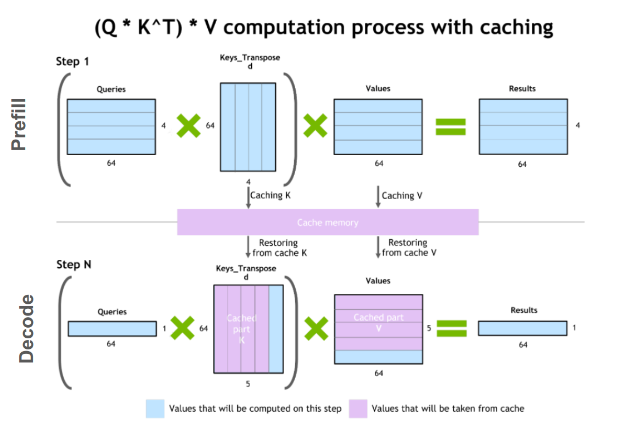

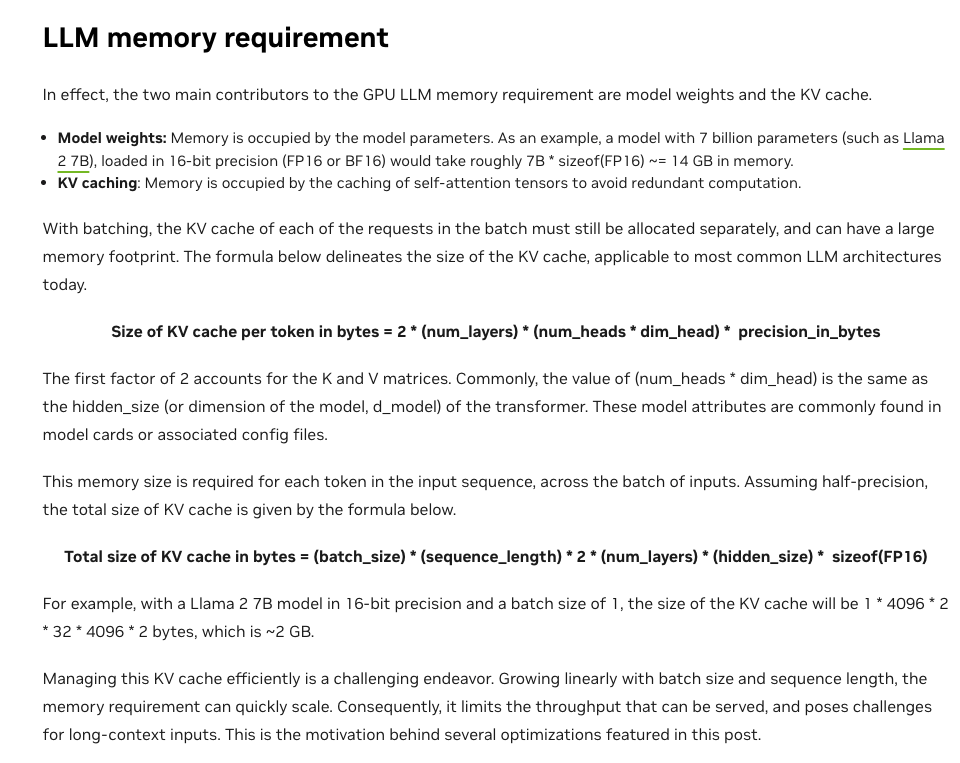

- The **initiation phase** is actually unaffected by the KV caching strategy since there are no previous steps.
- For the **decoding phase** however, the situation now looks very different. We no longer use the whole sequence as input but only the last generated token (and the KV cache).
- 
In the initiation phase, the attention layer now processes all the prompt’s tokens in one go as opposed to the decoding steps where it processes only one token at a time. In the literature, the first set up is called **batched attention** (sometimes misleadingly parallel attention) while the second incremental attention.

When resorting to KV caching, the initiation phase actually computes and (pre-)fills the KV cache with the key and the values of all the input tokens and is therefore often called pre-fill phase instead. In practice, the terms pre-fill and initiation phase are used interchangeably, we will favor the former starting from now.

This new difference between the initiation and generation phases is not merely conceptual. Now, at each generation step, in addition to the weight matrices, we have to fetch an ever growing cache from memory and only to process a single token per sequence. Notice that using GPU kernels optimized for each phase brings better performance than using the same one for both the pre-fill and the decoding phase with KV cache enabled

# LLM Memory Usage: Model Weights and KV Cache

## The Two Big Memory Hogs

When you load an LLM onto a GPU, its memory is filled primarily by two things:

1. **Model Weights**: These are the learned parameters of the model itself. Think of this as the model's "brain." This is a fixed size.
2. **KV Cache**: This is a dynamic block of memory that stores intermediate calculations (the Key/Value tensors from the attention mechanism) to speed up text generation. It grows
as the sequence gets longer.

---

## 1. Calculating Memory for Model Weights

This is the easy part. The memory needed is simply the number of parameters multiplied by the size of each parameter.

### Example
A 7 billion parameter model (like Llama 2 7B) using 16-bit precision (2 bytes per parameter).

**Calculation:**
7,000,000,000 parameters × 2 bytes/parameter = 14,000,000,000 bytes

**Result:** ~14 GB

This is the static cost just to load the model onto the GPU.

---

## 2. Calculating Memory for the KV Cache

This is more complex because the size depends on how long the sequence is and how many sequences you process at once (the batch size).

### Formula

Total KV Cache Size = batch_size × sequence_length × 2 × num_layers × hidden_size × precision_in_bytes

Let's break down the formula with an example:

### Example
Llama 2 7B, 16-bit precision, batch size of 1, and an (assumed) sequence length of 4096 tokens.

**Values for the formula:**
- `batch_size`: 1
- `sequence_length`: 4096
- `2`: To account for storing both a Key and a Value vector
- `num_layers`: 32 (the number of layers in Llama 2 7B)
- `hidden_size` (d_model): 4096 (the main vector dimension in Llama 2 7B)
- `precision_in_bytes`: 2 (for 16-bit precision)

**Calculation:**
1 × 4096 × 2 × 32 × 4096 × 2 = 2,147,483,648 bytes

**Convert bytes to gigabytes** (1 GB ≈ 1,073,741,824 bytes):
2,147,483,648 / 1,073,741,824 = 2 GB

**Result:** For just one sequence of 4096 tokens, the KV cache takes up an additional **2 GB** of VRAM on top of the 14 GB for the model weights.

---

## Why This Is a Problem

The KV cache presents several challenges:

### It grows linearly
If you double the batch size or the sequence length, you double the KV cache memory.

### It limits throughput
Because the cache can get so big, you can't fit a large batch of sequences onto the GPU at once, which slows down how many requests you can process.

### It challenges long-context
Processing very long documents (e.g., 100,000 tokens) becomes extremely difficult because the KV cache would become enormous and might not even fit in memory.


### How many FLOPs is spent in a single matrix multiplication? 

Multiplying a matrix of shape (n, p) with another matrix of size (p, m) approximately involves 2.m.n.p operations. 

The most computationally intensive part of the attention mechanism is the multiplication of the Query (Q) and Key (K) matrices: Q * K^T.


Let's define the terms for a single sequence in a single attention head:
* t: The sequence length (number of tokens).
* d_head: The dimension of the head.


The Q and K matrices both have the shape (t, d_head). To multiply them, we transpose K to get K^T, which has the shape (d_head, t).

Now we apply the formula from step 1 to Q(t, d_head) * K^T(d_head, t):
* n = t
* p = d_head
* m = t


Total FLOPs = 2 * t * t * d_head = `2 * d_head * t^2`.

Overall, attention scores computations hence require 2.b.n_layers.n_head.d_head.t^2=2.b.n_layers.d_model.t^2 FLOPs. 

This step simply scales the single-head calculation to account for the entire model and batch:
* b: The batch size (how many sequences are processed at once).
* n_layers: The number of transformer layers in the model.
* n_head: The number of attention heads in each layer.

So, the total cost is: b * n_layers * n_head * (cost of a single head).
Total FLOPs = b * n_layers * n_head * (2 * d_head * t^2) = `2 * b * n_layers * n_head * d_head * t^2`.

The text then uses the identity d_model = n_head * d_head (where d_model is the main dimension of the model) to simplify the expression to `2 * b * n_layers * d_model * t^2`.

The quadratic scaling with t now appears clearly.

This is the main takeaway. In the final formula, all terms (b, n_layers, d_model) are fixed hyperparameters of the model. The one variable that changes with the input
is `t`, the sequence length.


The presence of the `t^2` term means the computational cost grows quadratically with the length of the input.
* If you double the sequence length, the FLOPs for attention will quadruple (2² = 4).
* If you make the sequence 10 times longer, the FLOPs will increase by 100 times (10² = 100).

## How do these returned KV values look like? 

Let’s do some tensor counting. With KV caching enabled, the forward method returns a list of tensor pairs (one for the keys, one for the values). There are as many pairs as decoder blocks in the model (more commonly named decoder layers and noted n_layers). For each token of each sequence in the batch, there is one key/value vector of dimension d_head per attention head so each key/value tensor is therefore of shape (batch_size, seq_length, n_heads, d_head).

The cache isn't one giant block of data. It's organized logically:
* It's a list where each item corresponds to one layer of the transformer.
* Each item in the list is a pair of tensors: one for all the Keys in that layer, and one for all the Values.

> "each key/value tensor is therefore of shape (batch_size, n_heads, seq_length, d_head)."


This describes the dimensions of a single Key or Value tensor within a layer:
* batch_size: How many sequences you're generating in parallel.
* n_heads: The number of attention heads in that layer.
* seq_length: The length of the sequence generated so far. This dimension grows by 1 at each generation step.
* d_head: The size of the vector for each attention head.

4. A Concrete Example: Llama 2 7B


> "in Meta’s Llama2–7B for example, n_layers=32, n_heads=32 and d_head=128"


Let's apply the structure to this real-world model:
* The KV cache for Llama 2 7B is a list of 32 elements (one for each layer).
* Each element is a pair of (Key, Value) tensors.
* Each of these tensors has a shape of (batch_size, 32, seq_length, 128).


This also reveals why the KV cache is so memory-intensive. For a single sequence (batch_size=1) of 1024 tokens, the cache size (using 16-bit floats) would be:


32 (layers) * 2 (K/V) * 32 (heads) * 1024 (tokens) * 128 (dim) * 2 (bytes/float) ≈ 537 MB


This half-gigabyte of memory is just to store the cache for a single, moderately long sequence, explaining why running large models requires significant VRAM.


### Question
> for each token of each sequence in the batch, we need to store two vector tensors (one key tensor and one value tensor) of size d_head for each attention head of each attention layer. The space required by each tensor parameter depends on the precision: 4 bytes/parameter in full-precision (FP32), 2 bytes/parameter in half-precision (BF16, FP16), 1 byte/parameter for 8-bit data types (INT8, FP8), etc.

is kv cache for each sequence? why do we say it is for each token of each sequence?

### Ans

You are correct that the KV cache is maintained for each sequence. The phrasing "for each token of each sequence" can be confusing, but it's describing what the cache contains, not how many caches there are.


Let's clarify with an analogy.

Imagine the KV cache for a single sequence is like a notebook.


1. The Cache is "for each sequence": If you are processing a batch of 4 sentences (sequences), you will have 4 separate notebooks. This is your correct intuition. The
  batch_size dimension in the cache tensor handles this.


2. The Contents are "for each token": Now, what do you write inside one of those notebooks? You write down information for every token you process.
   * When the model processes the 1st token ("Hello"), it calculates its Key and Value vectors and writes them on Page 1 of the notebook.
   * When it processes the 2nd token ("world"), it calculates its Key and Value vectors and writes them on Page 2.
   * ...and so on.


After processing a 10-token sequence, the notebook for that sequence will have 10 pages, each containing the Key and Value vectors for one of the tokens.

Tying it Together

So, the phrase:

> "...for each token of each sequence... we need to store two vector tensors..."

...is a precise way of saying:


**The total memory required is the sum of the memory needed for every token that has been processed. The cache for a single sequence is not one single vector; it is a collection of vectors, with a new Key/Value pair being added for each token that is generated.**


This is why the seq_length dimension of the cache tensor (batch_size, n_heads, seq_length, d_head) grows by 1 at every step—you are adding the K/V information for one more token.

In short:


* You have one KV cache per sequence.
* That cache stores one K/V pair per token within that sequence.

### let’s have a look at all the ways we can reduce the memory footprint of the KV cache by taking the formula above and looking at each of its terms in turn:

> Total KV Cache Size = batch_size × sequence_length × 2 × num_layers × hidden_size × precision_in_bytes


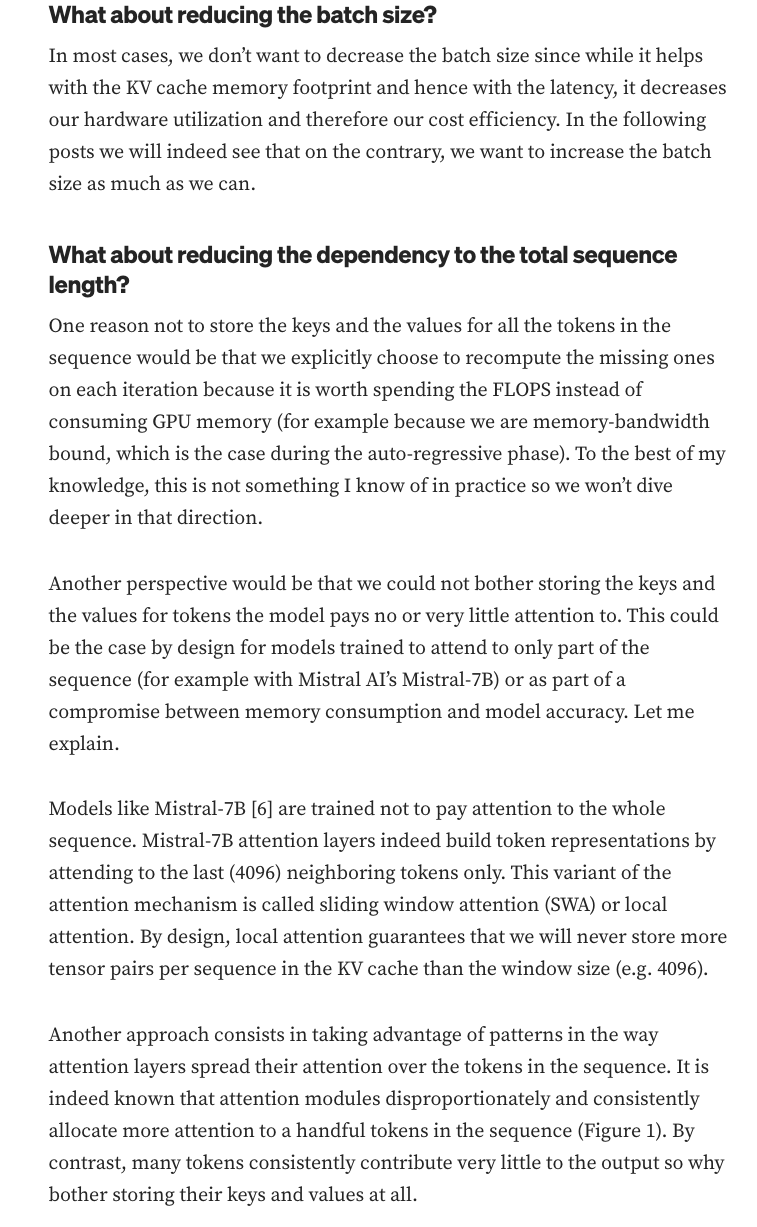

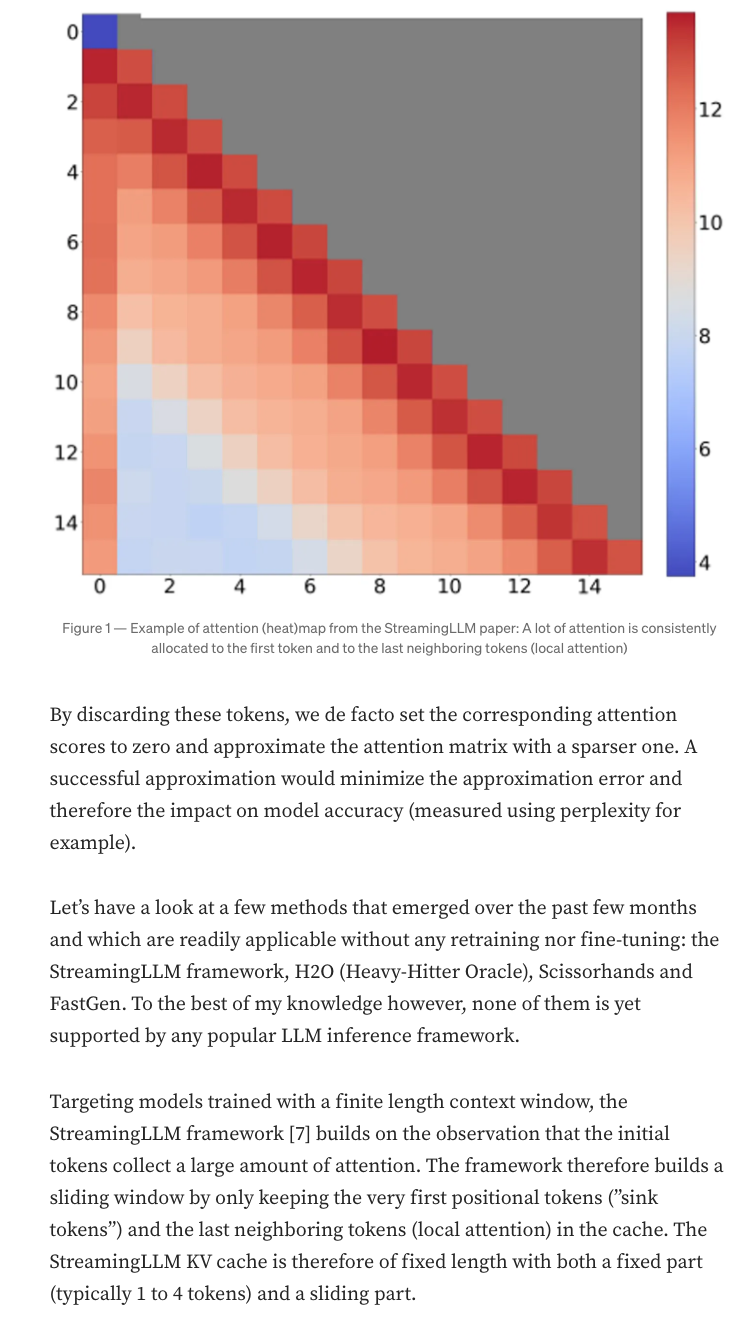

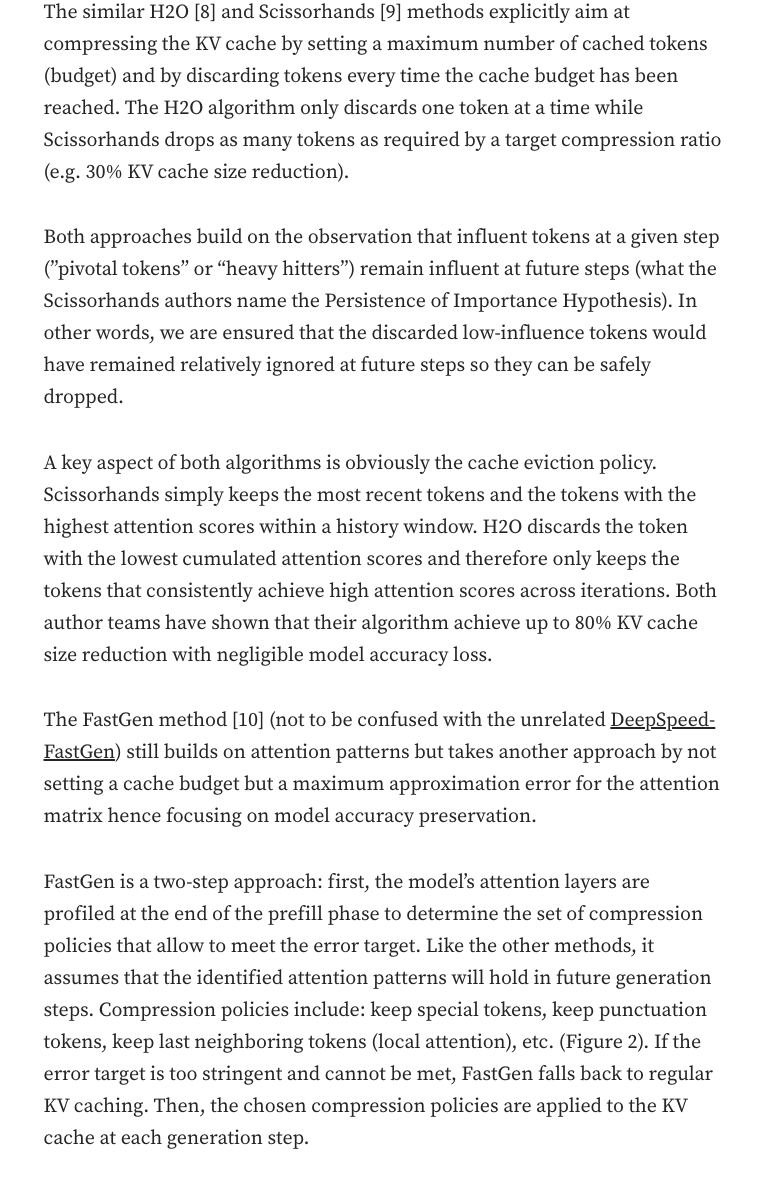

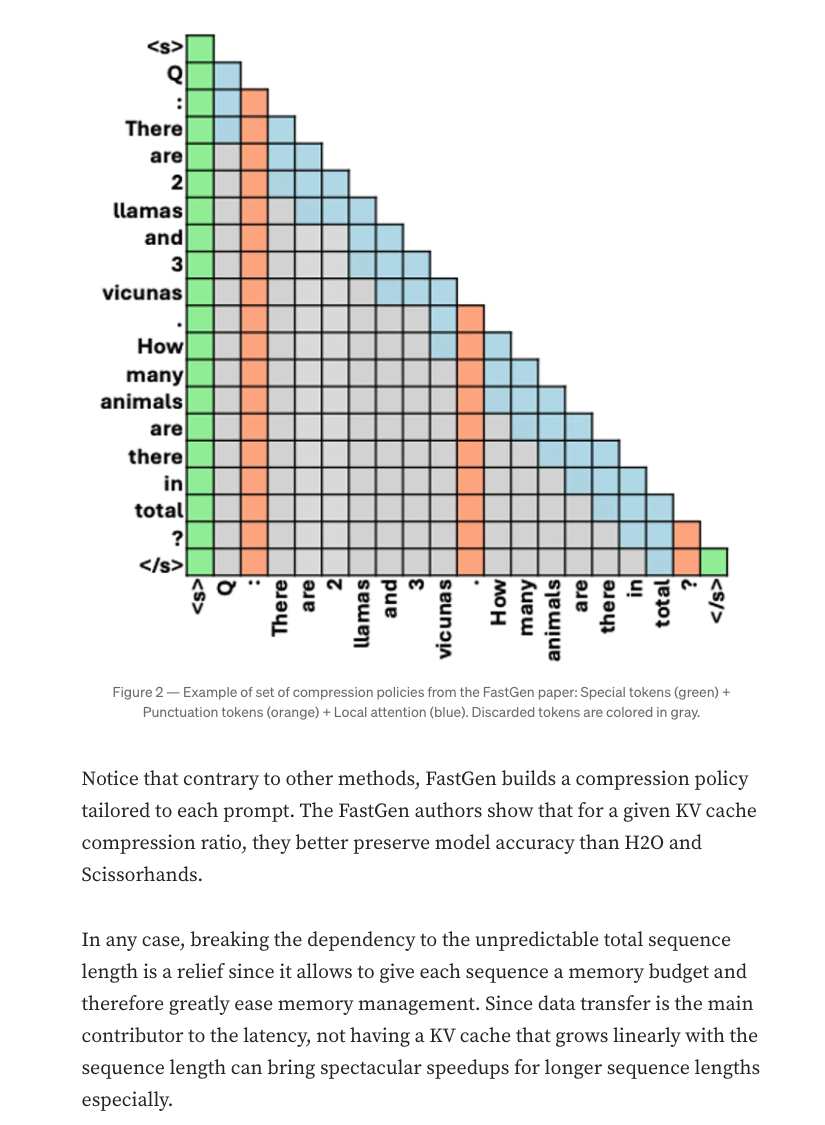

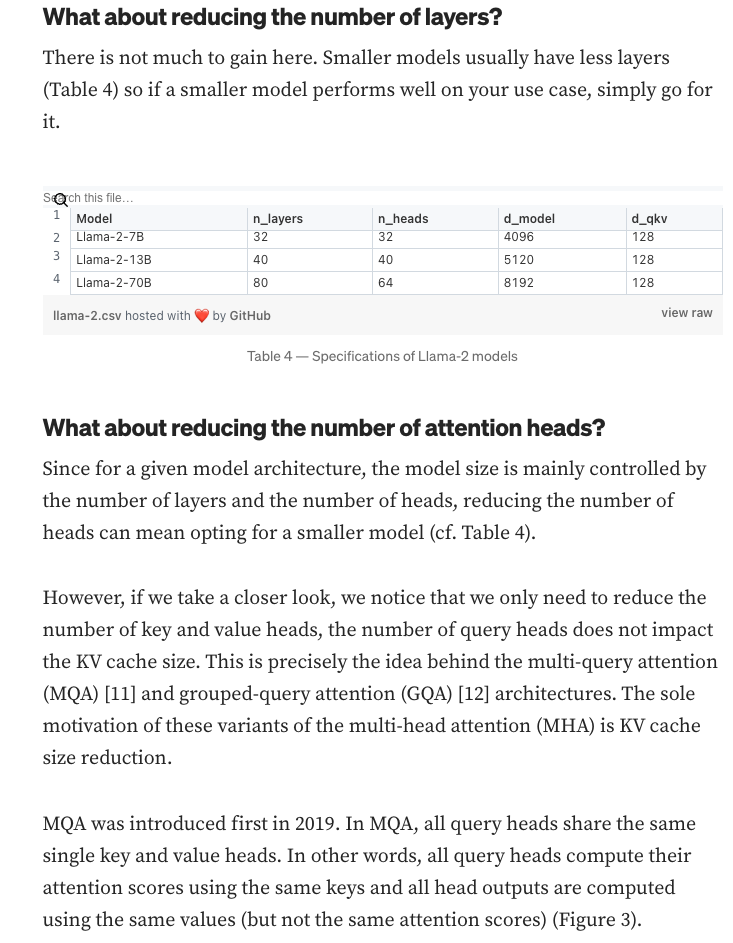

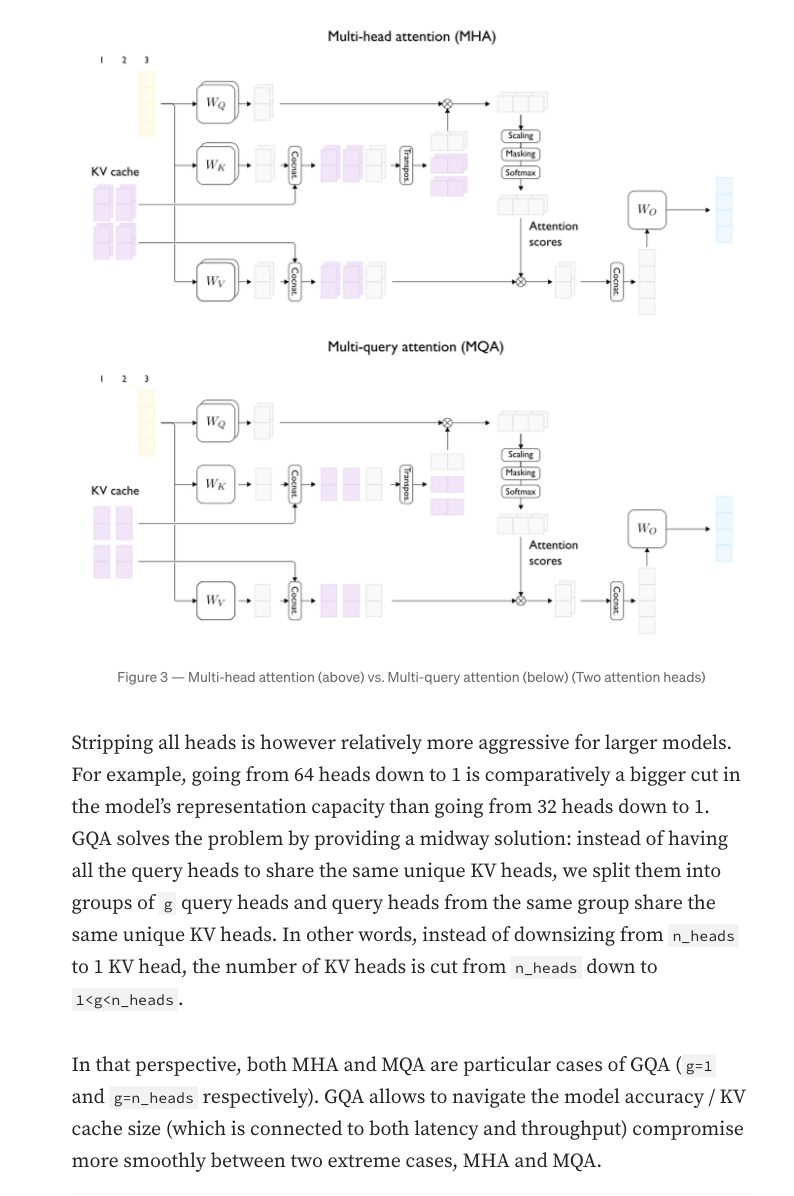

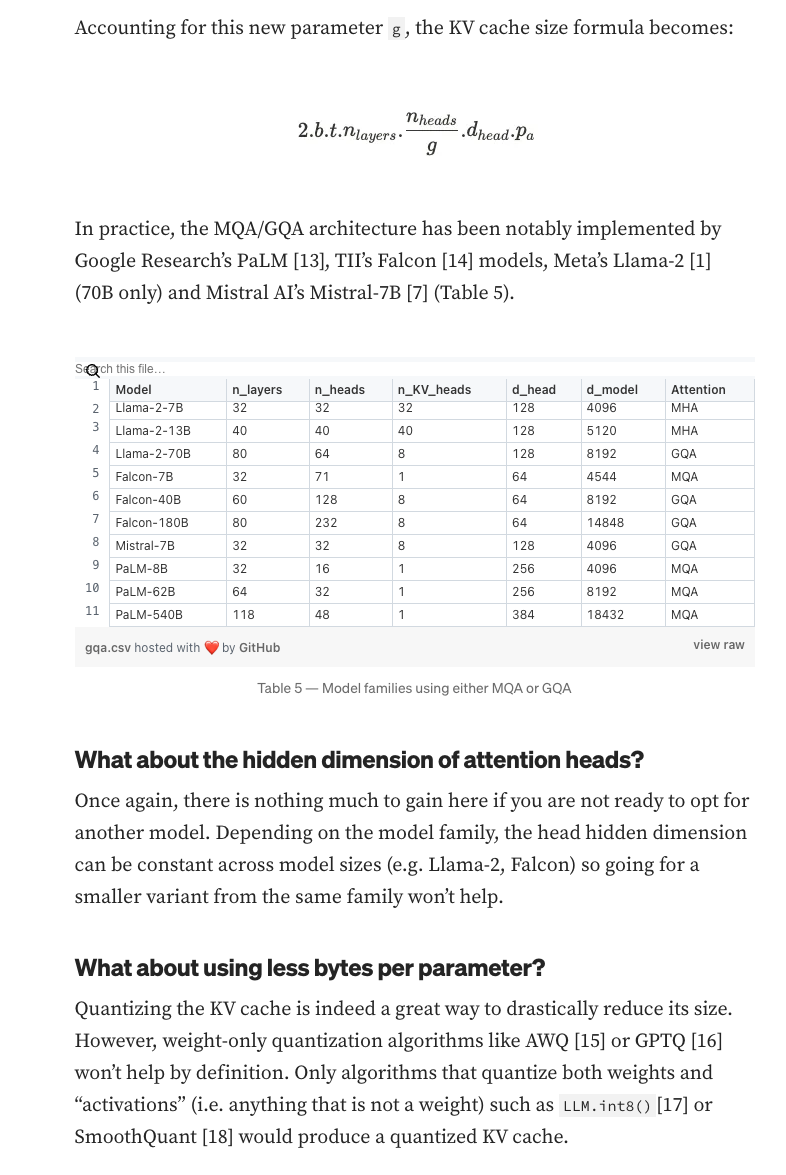

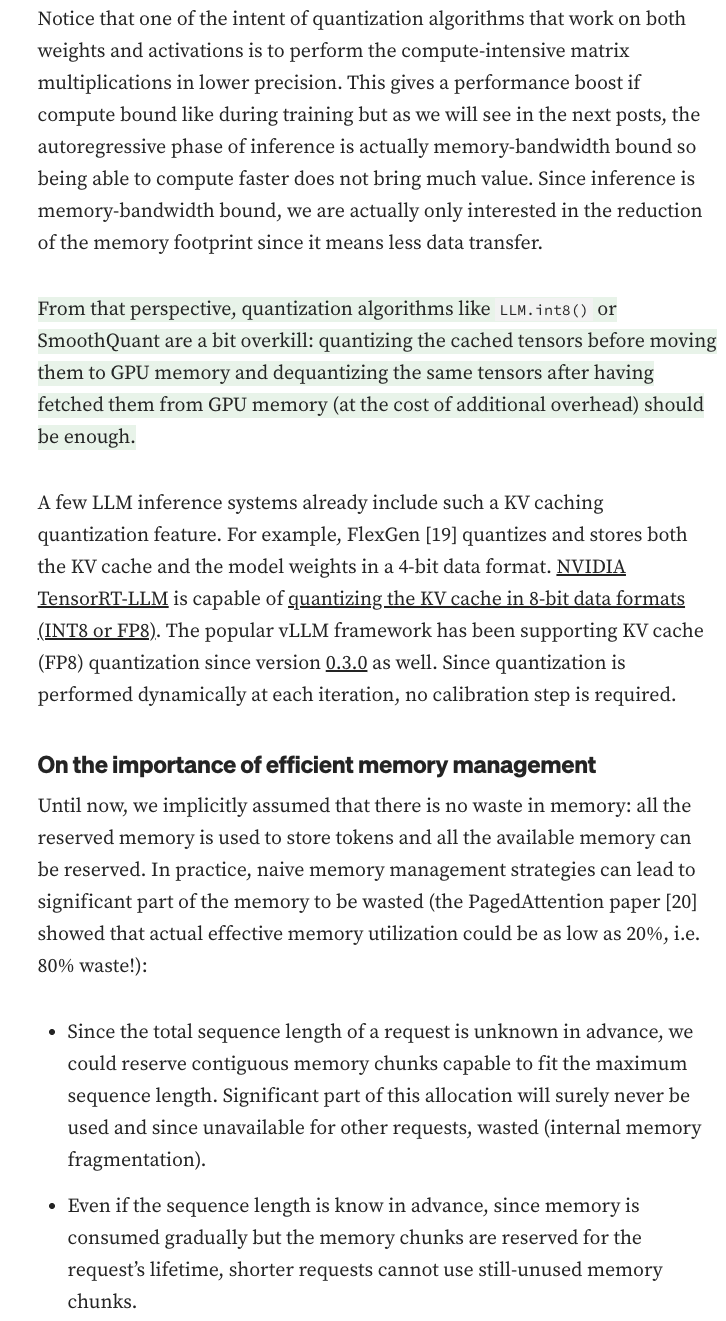

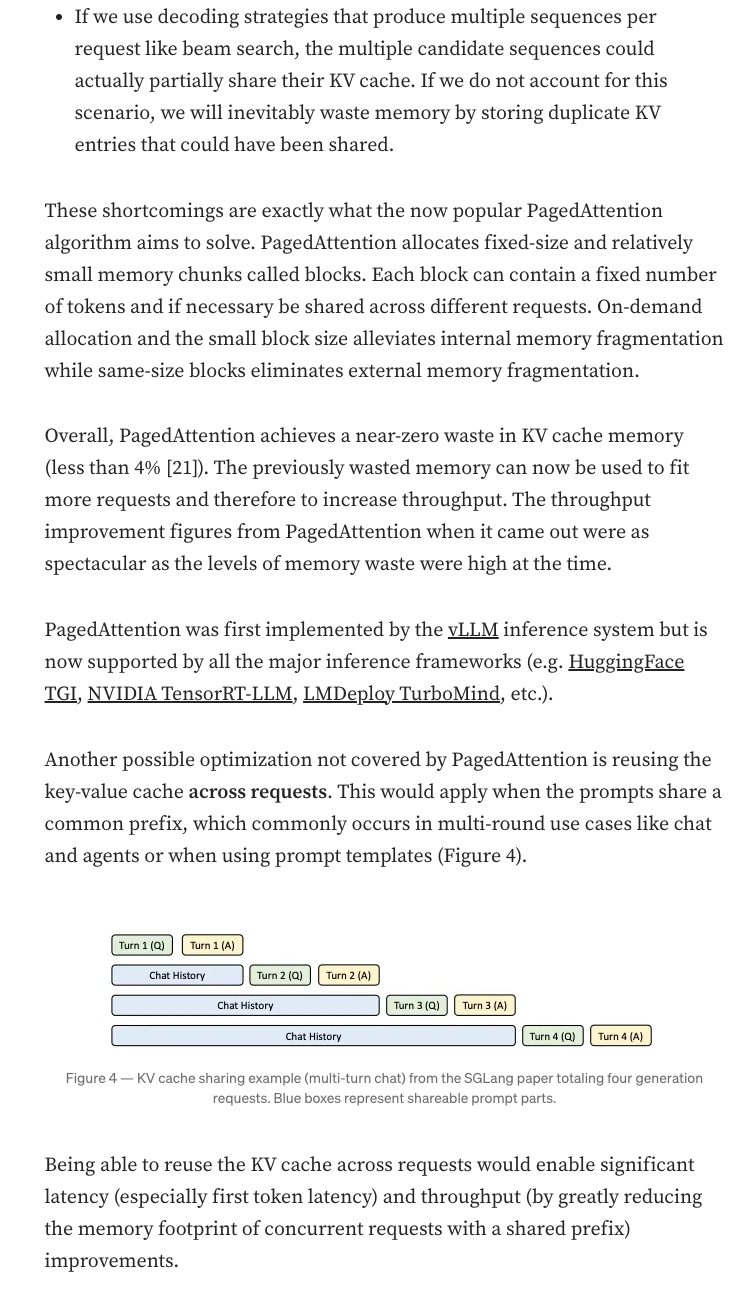

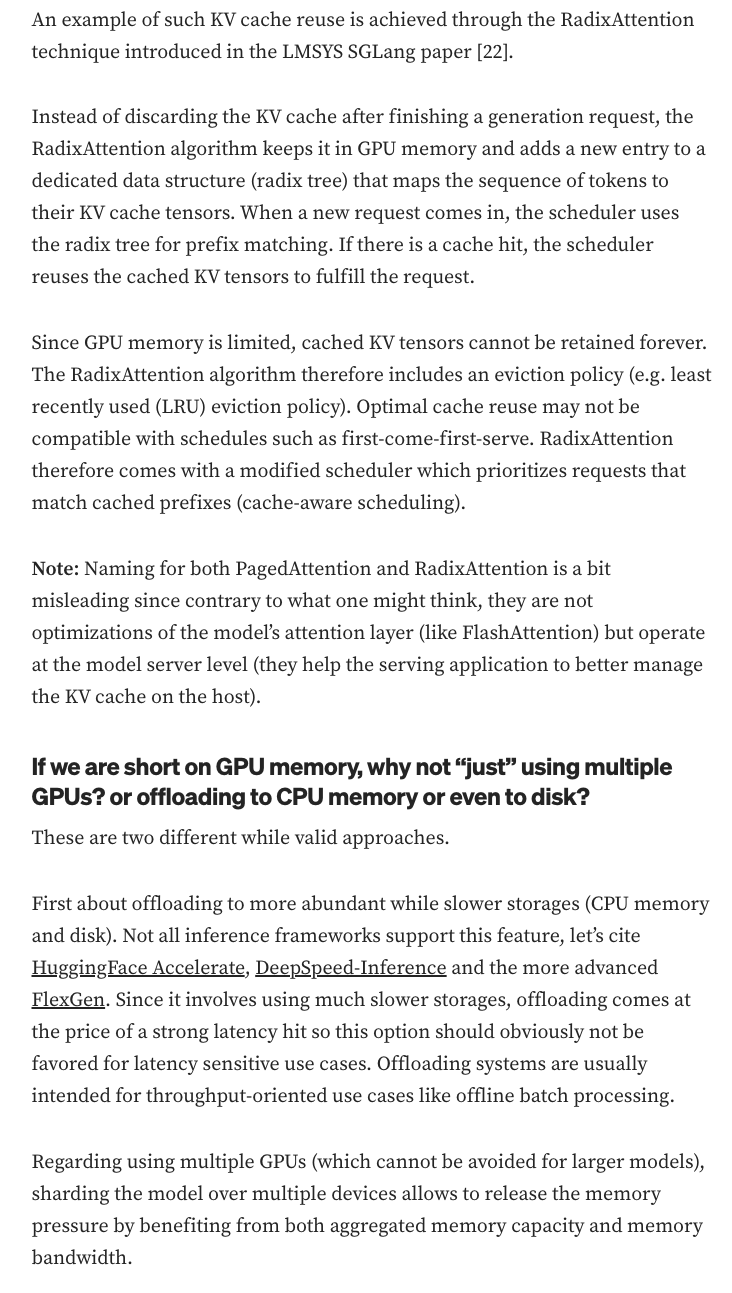

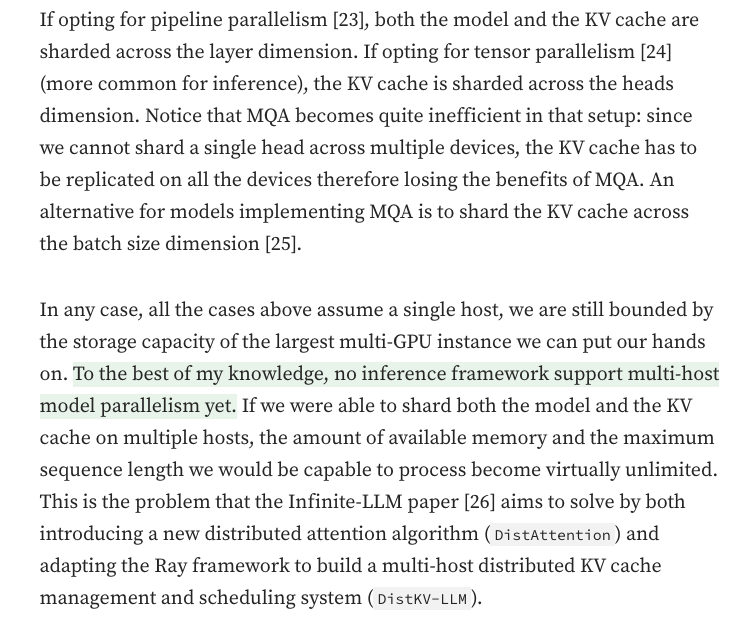

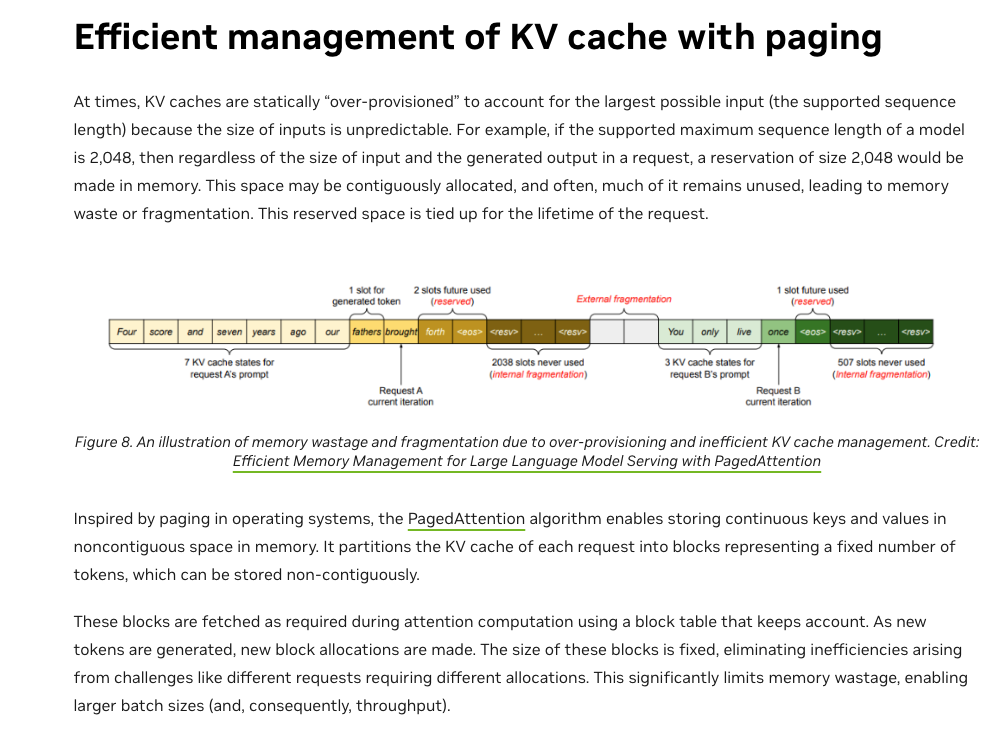

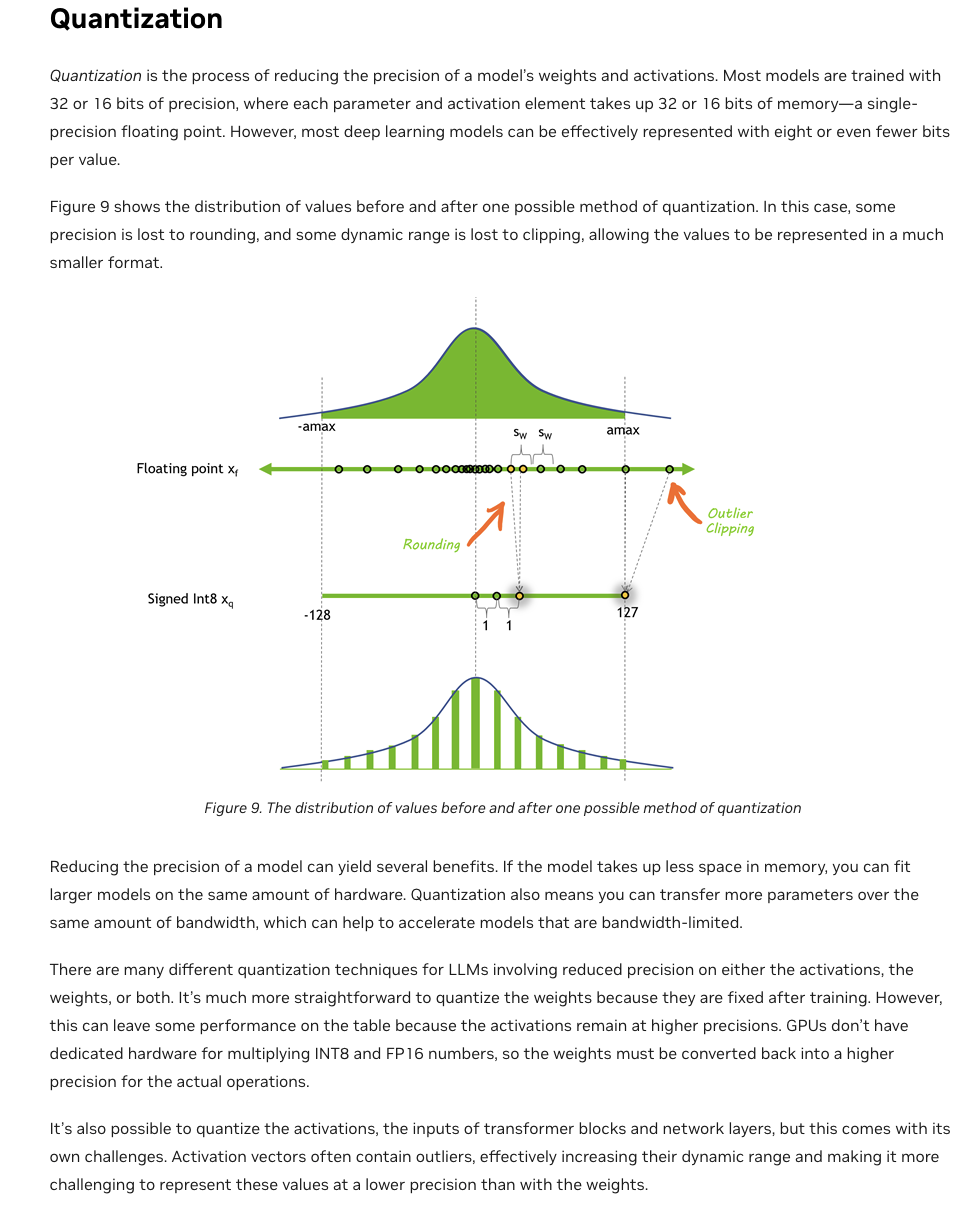

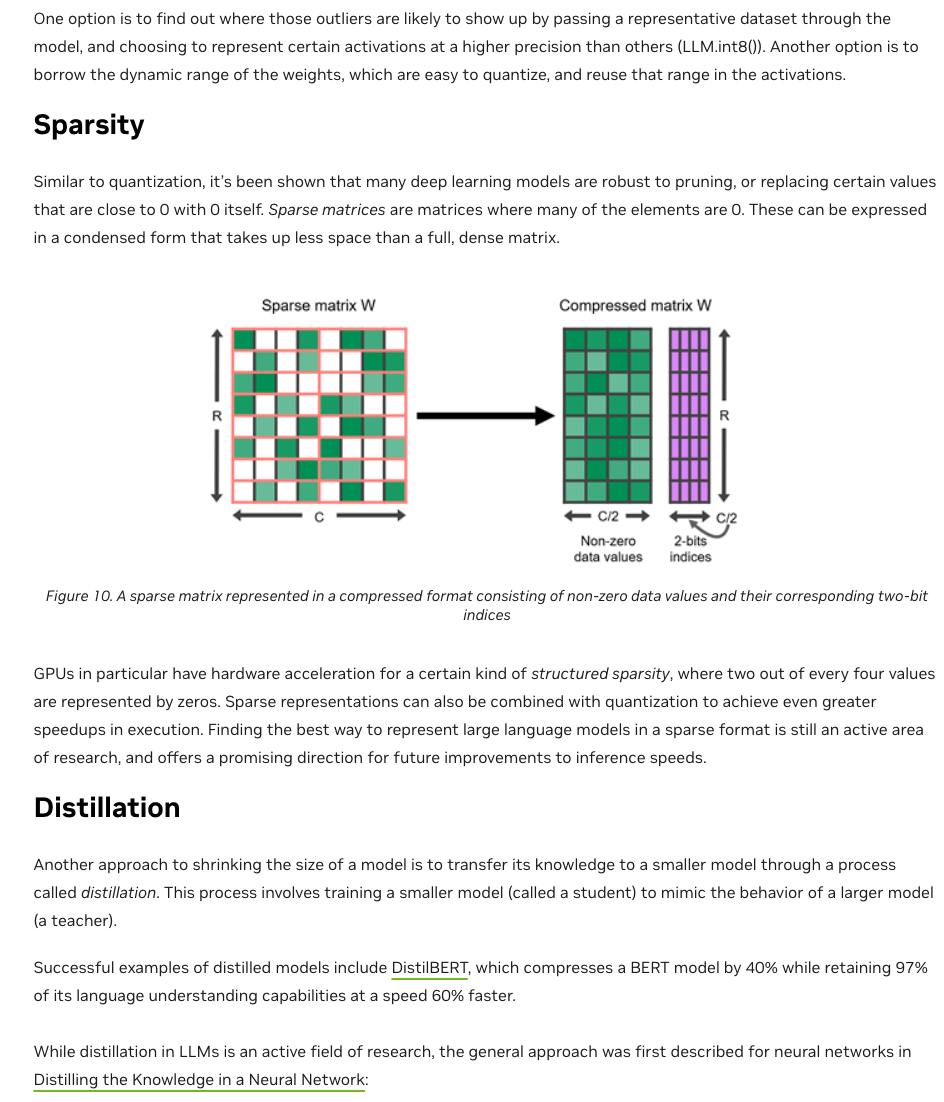

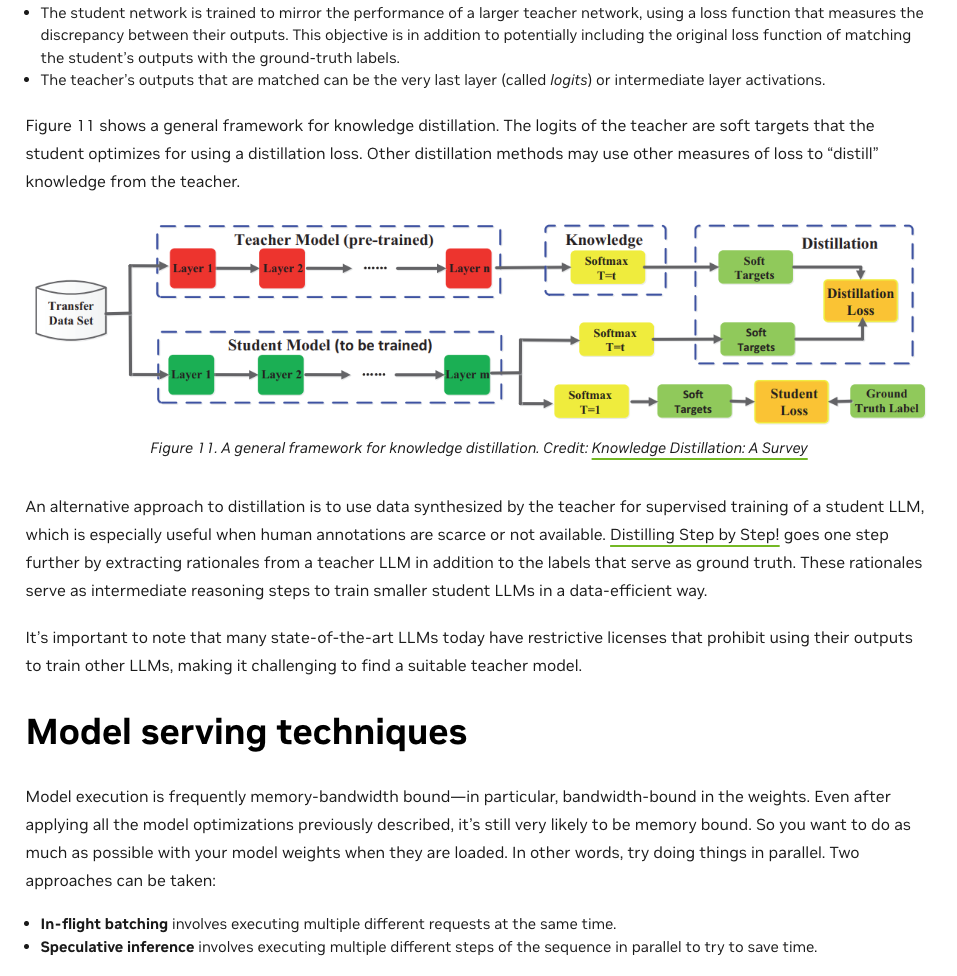

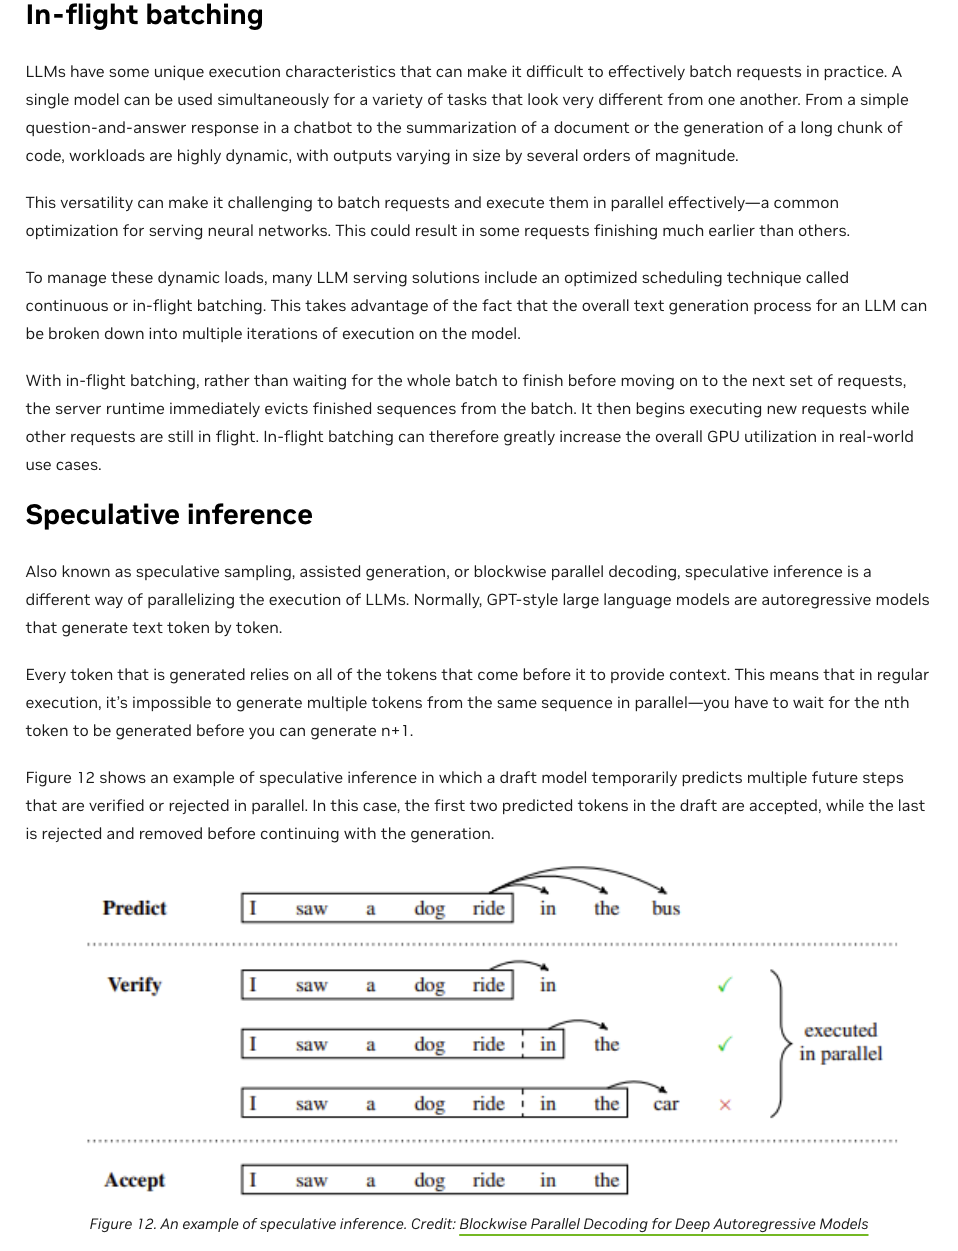

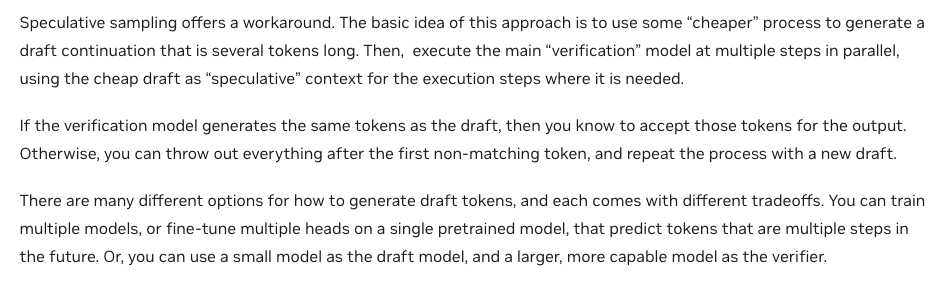



### REFERENCES

- https://developer.nvidia.com/blog/mastering-llm-techniques-inference-optimization/
- https://medium.com/@plienhar/llm-inference-series-3-kv-caching-unveiled-048152e461c8
- https://medium.com/@plienhar/llm-inference-series-4-kv-caching-a-deeper-look-4ba9a77746c8